<a href="https://colab.research.google.com/github/SathishDissanayaka/statistical-analysis-neural-network-depth/blob/main/predictive_analysis_representational_capacity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Analysis: Representational Capacity and Network Depth

**Research Topic:** *Training deeper models increases representational capacity.*

## Design Rationale

### Why `final_train_acc` at `corruption = 1.0` as the target?
At 100% label corruption, labels are entirely random — no pattern exists to generalise.
A model can only improve training accuracy by **memorising** individual samples, which requires
sufficient **representational capacity**. Therefore, `final_train_acc` under full corruption
is a clean proxy for capacity: the higher it is, the more the model can memorise, independent
of generalisation ability.

### Why split by regime?
- **iso_param**: depth ↑, width ↓, n_params ≈ constant. Isolates the effect of *architecture shape* on capacity.
- **fixed_width**: depth ↑, width fixed, n_params ↑. Depth and parameter count are **confounded** — a different analysis.

Training the same model on both would mix these two distinct mechanisms and obscure interpretation.

### Models
| Model | Type | Why |
|---|---|---|
| OLS Linear Regression | Interpretable | Baseline; coefficients directly quantify each feature's contribution |
| Lasso Regression | Interpretable | Regularised; shows which features survive shrinkage |
| Decision Tree (max_depth=4) | Interpretable | Non-linear; readable split logic; visualisable |
| Random Forest + SHAP | Black-box + XAI | Captures interactions; SHAP explains individual and global contributions |

**The goal is interpretation, not prediction accuracy.**

In [ ]:
# ── 0. Imports ────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Interpretable models
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error

# Explainable AI
import shap

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

SEED = 42
print('All imports successful.')

All imports successful.


In [ ]:
# ── 1. Load preprocessed data ─────────────────────────────────────────────────
# Assumes the preprocessing notebook has been run and produced `df`.
# If running standalone, re-run the preprocessing steps here.

df = pd.read_csv("/content/data_preprocessed - data_preprocessed.csv")

# --- Reproduce essential preprocessing inline ---
# df = df_raw[~df_raw['optimization_failure']].copy()
# df['gen_gap']              = df['final_train_acc'] - df['final_test_acc']
# df['epoch_fraction']       = df['actual_epochs'] / 120
# df['total_flops']          = df['flops_per_epoch'] * df['actual_epochs']
# df['log_n_params']         = np.log10(df['n_params'])
# df['log_total_flops']      = np.log10(df['total_flops'])
# df['depth_per_param']      = df['depth'] / df['n_params']
# df['loss_drop_10_to_final']= df['loss_ep10'] - df['final_train_loss']
# df['regime_code']          = (df['regime'] == 'fixed_width').astype(int)
# df['missing_ep30']         = df['loss_ep30'].isna()
# df['missing_ep60']         = df['loss_ep60'].isna()

print(f'Full dataset: {df.shape}')
print(f'Corruption levels: {sorted(df.corruption.unique())}')
print(f'Regimes: {df.regime.unique()}')

Full dataset: (900, 37)
Corruption levels: [np.float64(0.0), np.float64(0.1), np.float64(0.3), np.float64(0.6), np.float64(1.0)]
Regimes: ['iso_param' 'fixed_width']


In [ ]:
# ── 2. Isolate the representational capacity subset ───────────────────────────
#
# At corruption = 1.0, all labels are random.
# final_train_acc is a pure measure of memorisation capacity.

df_cap = df[df['corruption'] == 1.0].copy().reset_index(drop=True)

print(f'Capacity subset (corruption=1.0): {len(df_cap)} rows')
print(f'  iso_param:   {(df_cap.regime == "iso_param").sum()}')
print(f'  fixed_width: {(df_cap.regime == "fixed_width").sum()}')
print()
print('Target distribution (final_train_acc):')
print(df_cap.groupby('regime')['final_train_acc'].describe().round(4))

Capacity subset (corruption=1.0): 180 rows
  iso_param:   108
  fixed_width: 72

Target distribution (final_train_acc):
               count   mean    std    min    25%    50%    75%    max
regime                                                               
fixed_width  72.0000 0.9257 0.1186 0.5684 0.9255 0.9740 0.9998 1.0000
iso_param   108.0000 0.8383 0.2156 0.2514 0.8052 0.9256 0.9982 1.0000


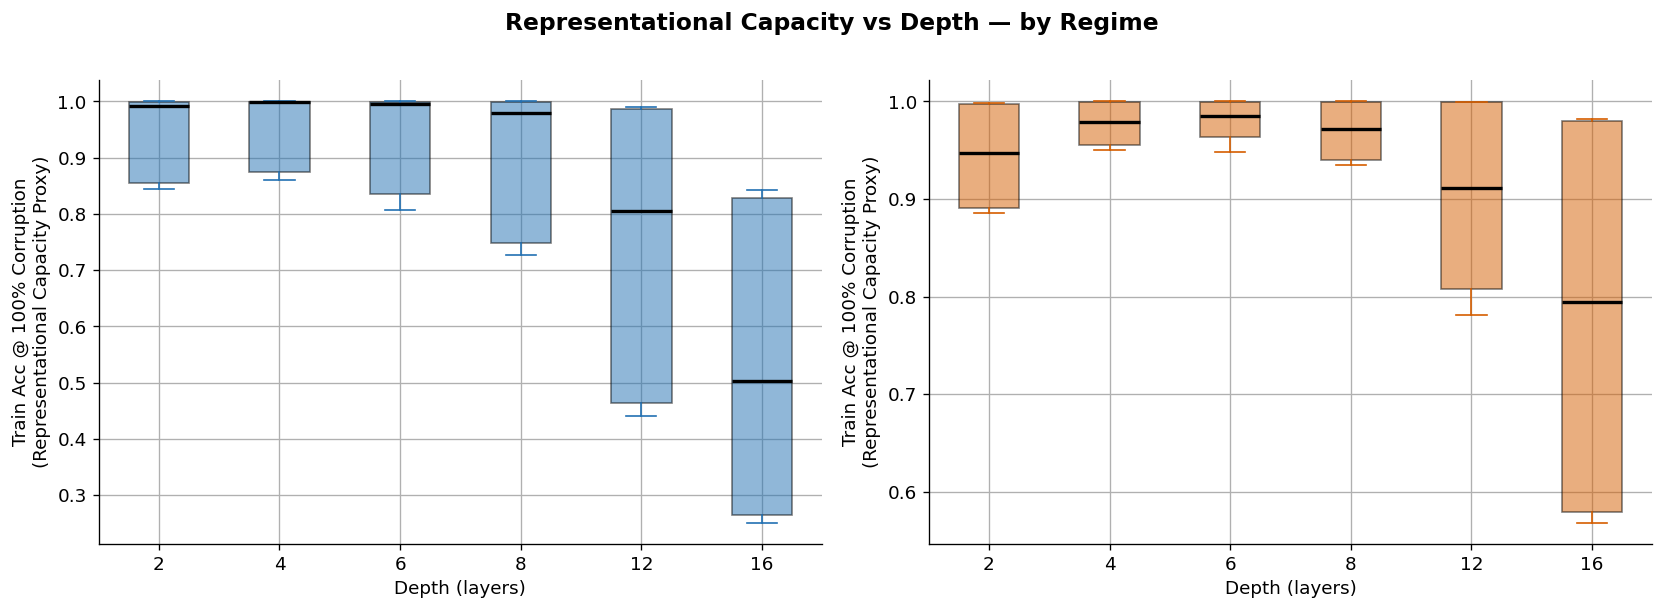


Mean capacity by (regime, depth):
depth           2      4      6      8      12     16
regime                                               
fixed_width 0.9440 0.9772 0.9802 0.9695 0.9016 0.7817
iso_param   0.9476 0.9552 0.9400 0.9069 0.7489 0.5313


In [ ]:
# ── 3. EDA: Capacity vs Depth by Regime ───────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, regime, color in zip(axes, ['iso_param', 'fixed_width'], ['#2271b3', '#d55e00']):
    sub = df_cap[df_cap['regime'] == regime]
    sub.boxplot(column='final_train_acc', by='depth', ax=ax,
                patch_artist=True,
                boxprops=dict(facecolor=color, alpha=0.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=color),
                capprops=dict(color=color),
                flierprops=dict(marker='o', color=color, alpha=0.4, markersize=4))
    ax.set_title(f'Regime: {regime}', fontweight='bold')
    ax.set_xlabel('Depth (layers)')
    ax.set_ylabel('Train Acc @ 100% Corruption\n(Representational Capacity Proxy)')
    plt.sca(ax)
    plt.title('')  # remove auto boxplot title

fig.suptitle('Representational Capacity vs Depth — by Regime', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nMean capacity by (regime, depth):')
print(df_cap.groupby(['regime', 'depth'])['final_train_acc']
      .mean().unstack('depth').round(4))

In [ ]:
# ── 4. Feature Set ────────────────────────────────────────────────────────────
#
# We use ARCHITECTURAL and TRAINING-CONVERGENCE features only.
# Loss trajectory features (loss_ep10 etc.) are excluded deliberately:
# we want to explain capacity from WHAT the model IS, not HOW it trained.
#
# Features:
#   depth          — layers (main variable of hypothesis)
#   width          — neurons per layer
#   log_n_params   — log10 of parameter count
#   depth_per_param — architectural shape: layers per parameter
#   epoch_fraction — fraction of max epochs used (convergence speed signal)
#   log_total_flops — total compute consumed

FEATURES = ['depth', 'width', 'log_n_params', 'depth_per_param',
            'epoch_fraction', 'log_total_flops']

TARGET = 'final_train_acc'

FEATURE_LABELS = {
    'depth':           'Depth (layers)',
    'width':           'Width (neurons/layer)',
    'log_n_params':    'log₁₀(N params)',
    'depth_per_param': 'Depth / N params',
    'epoch_fraction':  'Epoch fraction (convergence)',
    'log_total_flops': 'log₁₀(Total FLOPs)',
}

# Split by regime — complete cases only
df_iso   = df_cap[df_cap['regime'] == 'iso_param'][FEATURES + [TARGET]].dropna().copy()
df_fixed = df_cap[df_cap['regime'] == 'fixed_width'][FEATURES + [TARGET]].dropna().copy()

print(f'iso_param   — {len(df_iso)} rows, {df_iso[TARGET].isna().sum()} target NaN')
print(f'fixed_width — {len(df_fixed)} rows, {df_fixed[TARGET].isna().sum()} target NaN')

# Note: in fixed_width, `width` is constant per fixed_w group (64 or 128)
# — it will still be included for consistency; the model will discount it if uninformative.

# Scale features for linear models
scaler_iso   = StandardScaler()
scaler_fixed = StandardScaler()

X_iso   = df_iso[FEATURES].values
y_iso   = df_iso[TARGET].values

X_fixed = df_fixed[FEATURES].values
y_fixed = df_fixed[TARGET].values

X_iso_z   = scaler_iso.fit_transform(X_iso)
X_fixed_z = scaler_fixed.fit_transform(X_fixed)

print('\nCorrelation with target (final_train_acc @ corruption=1.0):')
for regime_label, sub_df in [('iso_param', df_iso), ('fixed_width', df_fixed)]:
    corr = sub_df.corr()[TARGET][FEATURES].round(3)
    print(f'\n  {regime_label}:')
    print(corr.to_string())

iso_param   — 108 rows, 0 target NaN
fixed_width — 72 rows, 0 target NaN

Correlation with target (final_train_acc @ corruption=1.0):

  iso_param:
depth             -0.6750
width              0.6470
log_n_params       0.5770
depth_per_param   -0.9490
epoch_fraction    -0.3510
log_total_flops    0.5810

  fixed_width:
depth             -0.4970
width              0.5990
log_n_params       0.2990
depth_per_param   -0.8130
epoch_fraction    -0.3320
log_total_flops    0.2850


---
## Model 1 — OLS Linear Regression (statsmodels)

**Purpose:** Establish a linear baseline with full statistical inference (p-values, confidence intervals, R²).  
**Interpretation key:** Standardised coefficients (β) tell us the relative importance of each feature. The sign of `depth` tells us the *direction* of the capacity–depth relationship, and the p-value tells us if it is statistically reliable.

In [ ]:
import statsmodels.api as sm
import pandas as pd # Ensure pandas is imported

def fit_ols(X_z, y, feature_names, regime_label):
    """Fit OLS with standardised features. Returns results object."""
    X_sm = sm.add_constant(X_z)
    # col_names = ['const'] + feature_names # This line is problematic due to multicollinearity handling

    model = sm.OLS(y, X_sm)
    result = model.fit()

    # Use the actual exogenous names from the fitted model
    col_names_actual = result.model.exog_names # <-- Fix applied here

    print(f'\n{"═"*60}')
    print(f' OLS — {regime_label}')
    print(f'{"═"*60}')
    print(f'  R²       = {result.rsquared:.4f}')
    print(f'  Adj. R²  = {result.rsquared_adj:.4f}')
    print(f'  F-stat   = {result.fvalue:.2f}  (p={result.f_pvalue:.4e})')
    print()

    coef_df = pd.DataFrame({
        'Feature':  col_names_actual, # Use actual names that match the number of coefficients
        'Coef (β)': result.params,
        'Std Err':  result.bse,
        't-stat':   result.tvalues,
        'p-value':  result.pvalues,
        'CI lower': result.conf_int()[0],
        'CI upper': result.conf_int()[1],
    }).set_index('Feature')
    print(coef_df.round(4).to_string())
    return result, coef_df

ols_iso_result,   ols_iso_coef   = fit_ols(X_iso_z,   y_iso,   FEATURES, 'iso_param')
ols_fixed_result, ols_fixed_coef = fit_ols(X_fixed_z, y_fixed, FEATURES, 'fixed_width')


════════════════════════════════════════════════════════════
 OLS — iso_param
════════════════════════════════════════════════════════════
  R²       = 0.9506
  Adj. R²  = 0.9477
  F-stat   = 324.26  (p=1.2565e-63)

         Coef (β)  Std Err   t-stat  p-value  CI lower  CI upper
Feature                                                         
const      0.8383   0.0047 176.6817   0.0000    0.8289    0.8477
x1        -0.2627   0.0269  -9.7494   0.0000   -0.3162   -0.2092
x2        -0.1832   0.0237  -7.7147   0.0000   -0.2303   -0.1361
x3         6.4251   2.0532   3.1293   0.0023    2.3521   10.4981
x4        -0.0765   0.0282  -2.7130   0.0078   -0.1324   -0.0206
x5         0.5591   0.1782   3.1373   0.0022    0.2056    0.9127
x6        -5.9105   1.9805  -2.9843   0.0036   -9.8393   -1.9817

════════════════════════════════════════════════════════════
 OLS — fixed_width
════════════════════════════════════════════════════════════
  R²       = 0.9059
  Adj. R²  = 0.8972
  F-stat   = 104

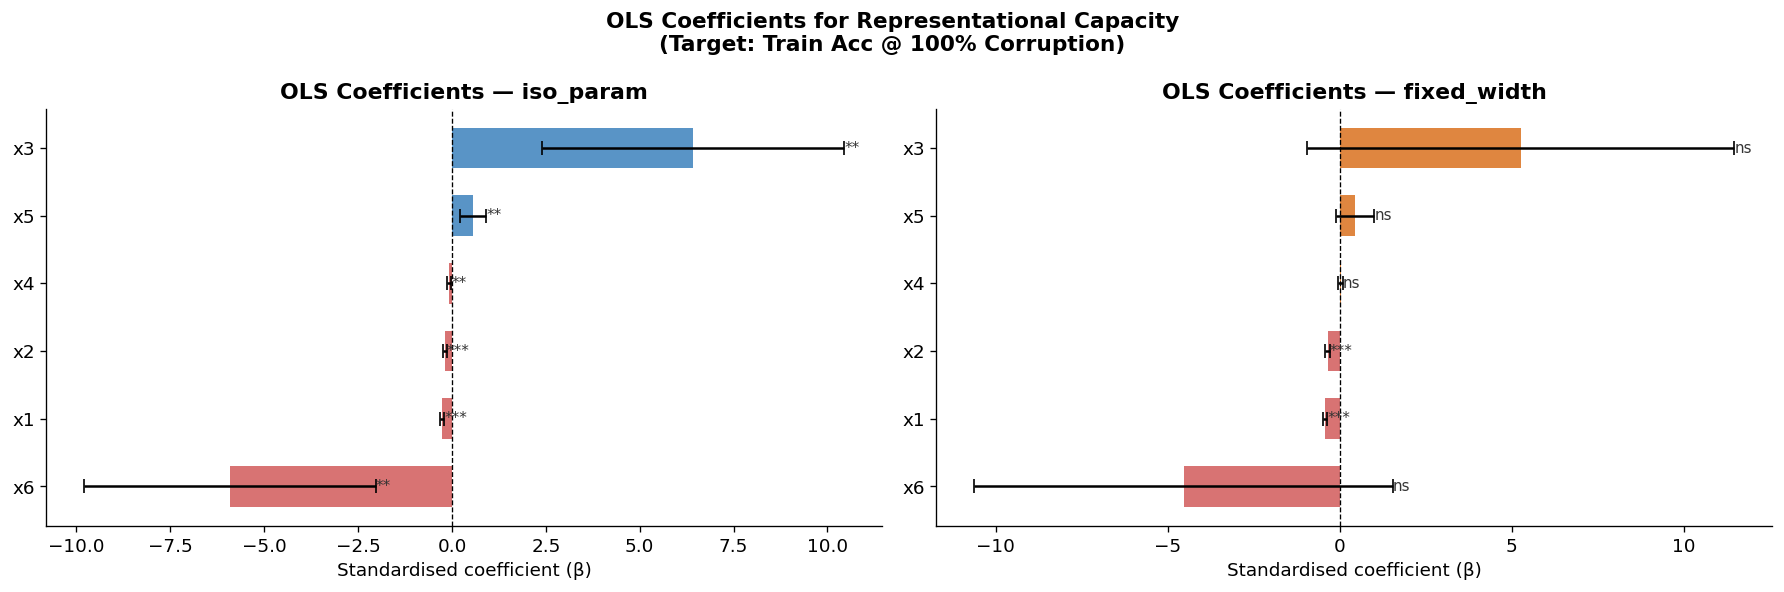


── Interpretation Guide ──
  Positive depth coef  → deeper models have MORE capacity (supports hypothesis)
  *** / ** / *         → statistically significant (p < 0.001 / 0.01 / 0.05)
  ns                   → not significant
  iso_param depth coef → PURE depth effect (parameters held constant)
  fixed_width depth coef → confounded with parameter count


In [ ]:
# ── OLS: Coefficient Plot ──────────────────────────────────────────────────────

def plot_coef(coef_df, regime_label, ax, color):
    sub = coef_df.drop('const').copy()
    sub = sub.sort_values('Coef (β)')
    y_pos = range(len(sub))
    labels = [FEATURE_LABELS.get(f, f) for f in sub.index]

    ax.barh(y_pos, sub['Coef (β)'], xerr=1.96 * sub['Std Err'],
            color=[color if v >= 0 else '#cc4444' for v in sub['Coef (β)']],
            alpha=0.75, capsize=4, height=0.6)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(labels)
    ax.set_xlabel('Standardised coefficient (β)')
    ax.set_title(f'OLS Coefficients — {regime_label}', fontweight='bold')

    # Significance stars
    for i, (idx, row) in enumerate(sub.iterrows()):
        sig = '***' if row['p-value'] < 0.001 else ('**' if row['p-value'] < 0.01
              else ('*' if row['p-value'] < 0.05 else 'ns'))
        offset = 0.002
        ax.text(row['Coef (β)'] + (1.96 * row['Std Err']) + offset, i, sig,
                va='center', fontsize=9, color='#333333')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_coef(ols_iso_coef,   'iso_param',   axes[0], '#2271b3')
plot_coef(ols_fixed_coef, 'fixed_width', axes[1], '#d55e00')

fig.suptitle('OLS Coefficients for Representational Capacity\n'
             '(Target: Train Acc @ 100% Corruption)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ols_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n── Interpretation Guide ──')
print('  Positive depth coef  → deeper models have MORE capacity (supports hypothesis)')
print('  *** / ** / *         → statistically significant (p < 0.001 / 0.01 / 0.05)')
print('  ns                   → not significant')
print('  iso_param depth coef → PURE depth effect (parameters held constant)')
print('  fixed_width depth coef → confounded with parameter count')

---
## Model 2 — Lasso Regression (Feature Selection via Regularisation)

**Purpose:** L1 regularisation drives uninformative features' coefficients exactly to zero, yielding an automatic feature selection. Features that survive (non-zero coefficients) are robustly associated with capacity.  
**Interpretation key:** Which features survive? Does `depth` survive? What is its sign?

In [ ]:
# ── Model 2: Lasso (alpha selected via 10-fold CV) ────────────────────────────

def fit_lasso(X_z, y, feature_names, regime_label):
    cv = KFold(n_splits=10, shuffle=True, random_state=SEED)
    lasso_cv = LassoCV(cv=cv, max_iter=10000, random_state=SEED)
    lasso_cv.fit(X_z, y)

    alpha_star = lasso_cv.alpha_
    coef = lasso_cv.coef_

    r2  = r2_score(y, lasso_cv.predict(X_z))
    mae = mean_absolute_error(y, lasso_cv.predict(X_z))

    print(f'\n{"═"*60}')
    print(f' Lasso — {regime_label}')
    print(f'{"═"*60}')
    print(f'  Optimal alpha (CV): {alpha_star:.6f}')
    print(f'  R² (train)        : {r2:.4f}')
    print(f'  MAE (train)       : {mae:.4f}')
    print()

    coef_df = pd.DataFrame({'Feature': feature_names, 'Lasso Coef': coef})
    coef_df['Survived'] = coef_df['Lasso Coef'] != 0
    print(coef_df.set_index('Feature').round(6).to_string())

    n_zero = (coef == 0).sum()
    print(f'\n  Features zeroed out: {n_zero} / {len(feature_names)}')
    return lasso_cv, coef_df

lasso_iso,   lasso_iso_coef   = fit_lasso(X_iso_z,   y_iso,   FEATURES, 'iso_param')
lasso_fixed, lasso_fixed_coef = fit_lasso(X_fixed_z, y_fixed, FEATURES, 'fixed_width')


════════════════════════════════════════════════════════════
 Lasso — iso_param
════════════════════════════════════════════════════════════
  Optimal alpha (CV): 0.000204
  R² (train)        : 0.9461
  MAE (train)       : 0.0423

                 Lasso Coef  Survived
Feature                              
depth               -0.2158      True
width               -0.1964      True
log_n_params         0.2633      True
depth_per_param     -0.0321      True
epoch_fraction       0.0243      True
log_total_flops      0.0170      True

  Features zeroed out: 0 / 6

════════════════════════════════════════════════════════════
 Lasso — fixed_width
════════════════════════════════════════════════════════════
  Optimal alpha (CV): 0.000096
  R² (train)        : 0.9022
  MAE (train)       : 0.0314

                 Lasso Coef  Survived
Feature                              
depth               -0.4135      True
width               -0.3506      True
log_n_params         0.5431      True
depth_per_

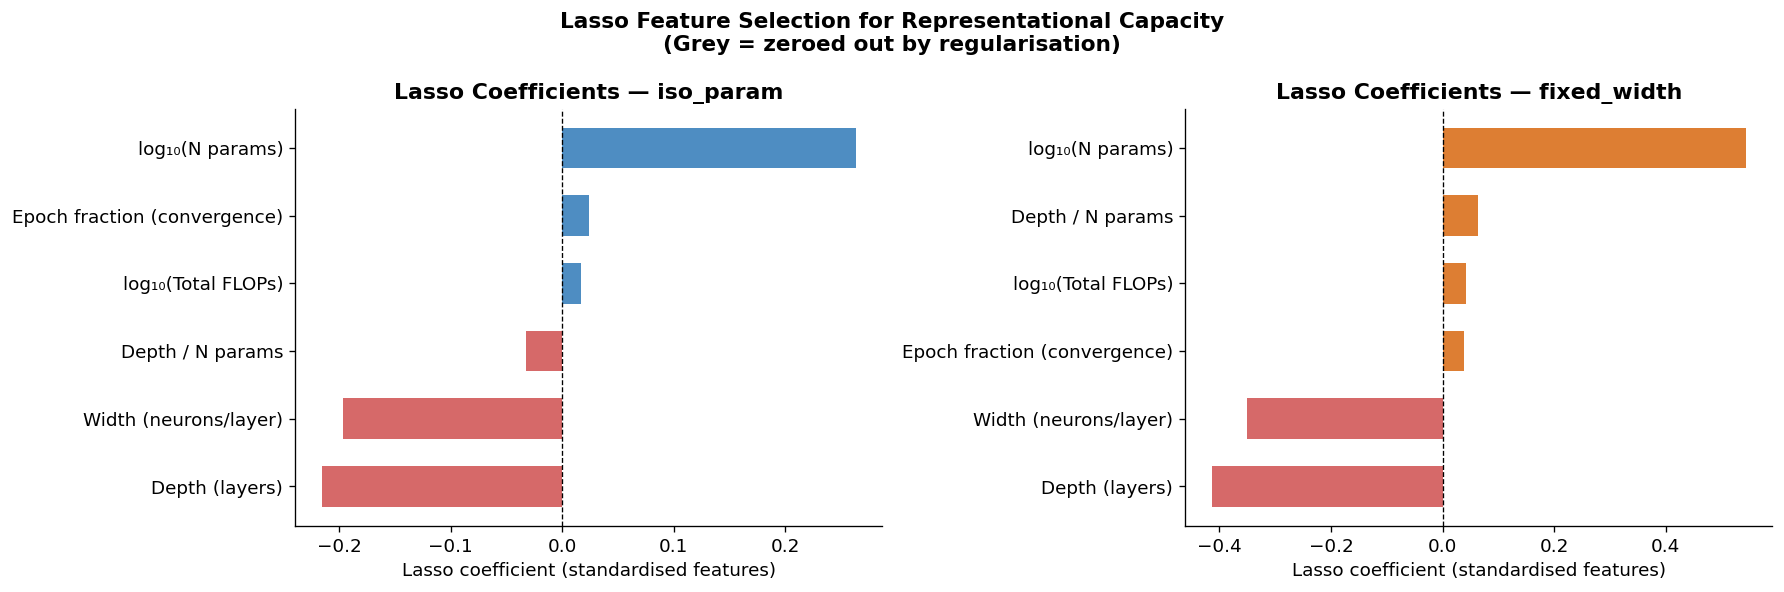

In [ ]:
# ── Lasso: Coefficient plot with survival highlighting ────────────────────────

def plot_lasso_coef(coef_df, regime_label, ax, color):
    sub = coef_df.sort_values('Lasso Coef').copy()
    labels = [FEATURE_LABELS.get(f, f) for f in sub['Feature']]
    y_pos  = range(len(sub))

    bar_colors = []
    for _, row in sub.iterrows():
        if not row['Survived']:
            bar_colors.append('#cccccc')   # zeroed out
        elif row['Lasso Coef'] >= 0:
            bar_colors.append(color)
        else:
            bar_colors.append('#cc4444')

    ax.barh(y_pos, sub['Lasso Coef'], color=bar_colors, alpha=0.8, height=0.6)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(labels)
    ax.set_xlabel('Lasso coefficient (standardised features)')
    ax.set_title(f'Lasso Coefficients — {regime_label}', fontweight='bold')

    for i, (_, row) in enumerate(sub.iterrows()):
        status = '' if row['Survived'] else ' ← zeroed'
        if status:
            ax.text(0.002, i, status, va='center', fontsize=8, color='#888888')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_lasso_coef(lasso_iso_coef,   'iso_param',   axes[0], '#2271b3')
plot_lasso_coef(lasso_fixed_coef, 'fixed_width', axes[1], '#d55e00')

fig.suptitle('Lasso Feature Selection for Representational Capacity\n'
             '(Grey = zeroed out by regularisation)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lasso_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Model 3 — Decision Tree Regressor (max_depth = 4)

**Purpose:** Captures non-linear threshold effects without assumptions. A shallow tree is fully human-readable — every split is a decision rule.  
**Interpretation key:** Which feature does the root split on? This is the single most important variable. Subsequent splits reveal the interaction structure. `depth` appearing early signals a non-linear capacity effect.

In [ ]:
# ── Model 3: Decision Tree ─────────────────────────────────────────────────────

def fit_dtree(X, y, feature_names, regime_label, max_depth=4):
    # Decision trees don't need scaling — use raw features for legible split thresholds
    dt = DecisionTreeRegressor(max_depth=max_depth, min_samples_leaf=3,
                               random_state=SEED)
    dt.fit(X, y)

    cv    = KFold(n_splits=10, shuffle=True, random_state=SEED)
    cv_r2 = cross_val_score(dt, X, y, cv=cv, scoring='r2')

    print(f'\n{"═"*60}')
    print(f' Decision Tree (max_depth={max_depth}) — {regime_label}')
    print(f'{"═"*60}')
    print(f'  R² (train)        : {r2_score(y, dt.predict(X)):.4f}')
    print(f'  R² (10-fold CV)   : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
    print()

    # Feature importances
    imp = pd.Series(dt.feature_importances_, index=feature_names)\
            .sort_values(ascending=False)
    print('  Feature importances (Gini):')
    for feat, val in imp.items():
        label = FEATURE_LABELS.get(feat, feat)
        bar   = '█' * int(val * 40)
        print(f'    {label:<35} {val:.4f}  {bar}')

    print()
    print('  Text representation of tree:')
    tree_text = export_text(dt, feature_names=feature_names, decimals=4)
    print(tree_text)
    return dt

dt_iso   = fit_dtree(X_iso,   y_iso,   FEATURES, 'iso_param')
dt_fixed = fit_dtree(X_fixed, y_fixed, FEATURES, 'fixed_width')


════════════════════════════════════════════════════════════
 Decision Tree (max_depth=4) — iso_param
════════════════════════════════════════════════════════════
  R² (train)        : 0.9984
  R² (10-fold CV)   : 0.9967 ± 0.0025

  Feature importances (Gini):
    Depth / N params                    0.8342  █████████████████████████████████
    Depth (layers)                      0.1045  ████
    Width (neurons/layer)               0.0386  █
    log₁₀(Total FLOPs)                  0.0226  
    log₁₀(N params)                     0.0000  
    Epoch fraction (convergence)        0.0000  

  Text representation of tree:
|--- depth_per_param <= 0.0001
|   |--- depth_per_param <= 0.0001
|   |   |--- log_total_flops <= 11.2057
|   |   |   |--- value: [0.8504]
|   |   |--- log_total_flops >  11.2057
|   |   |   |--- depth_per_param <= 0.0001
|   |   |   |   |--- value: [0.9967]
|   |   |   |--- depth_per_param >  0.0001
|   |   |   |   |--- value: [0.9792]
|   |--- depth_per_param >  0.0001


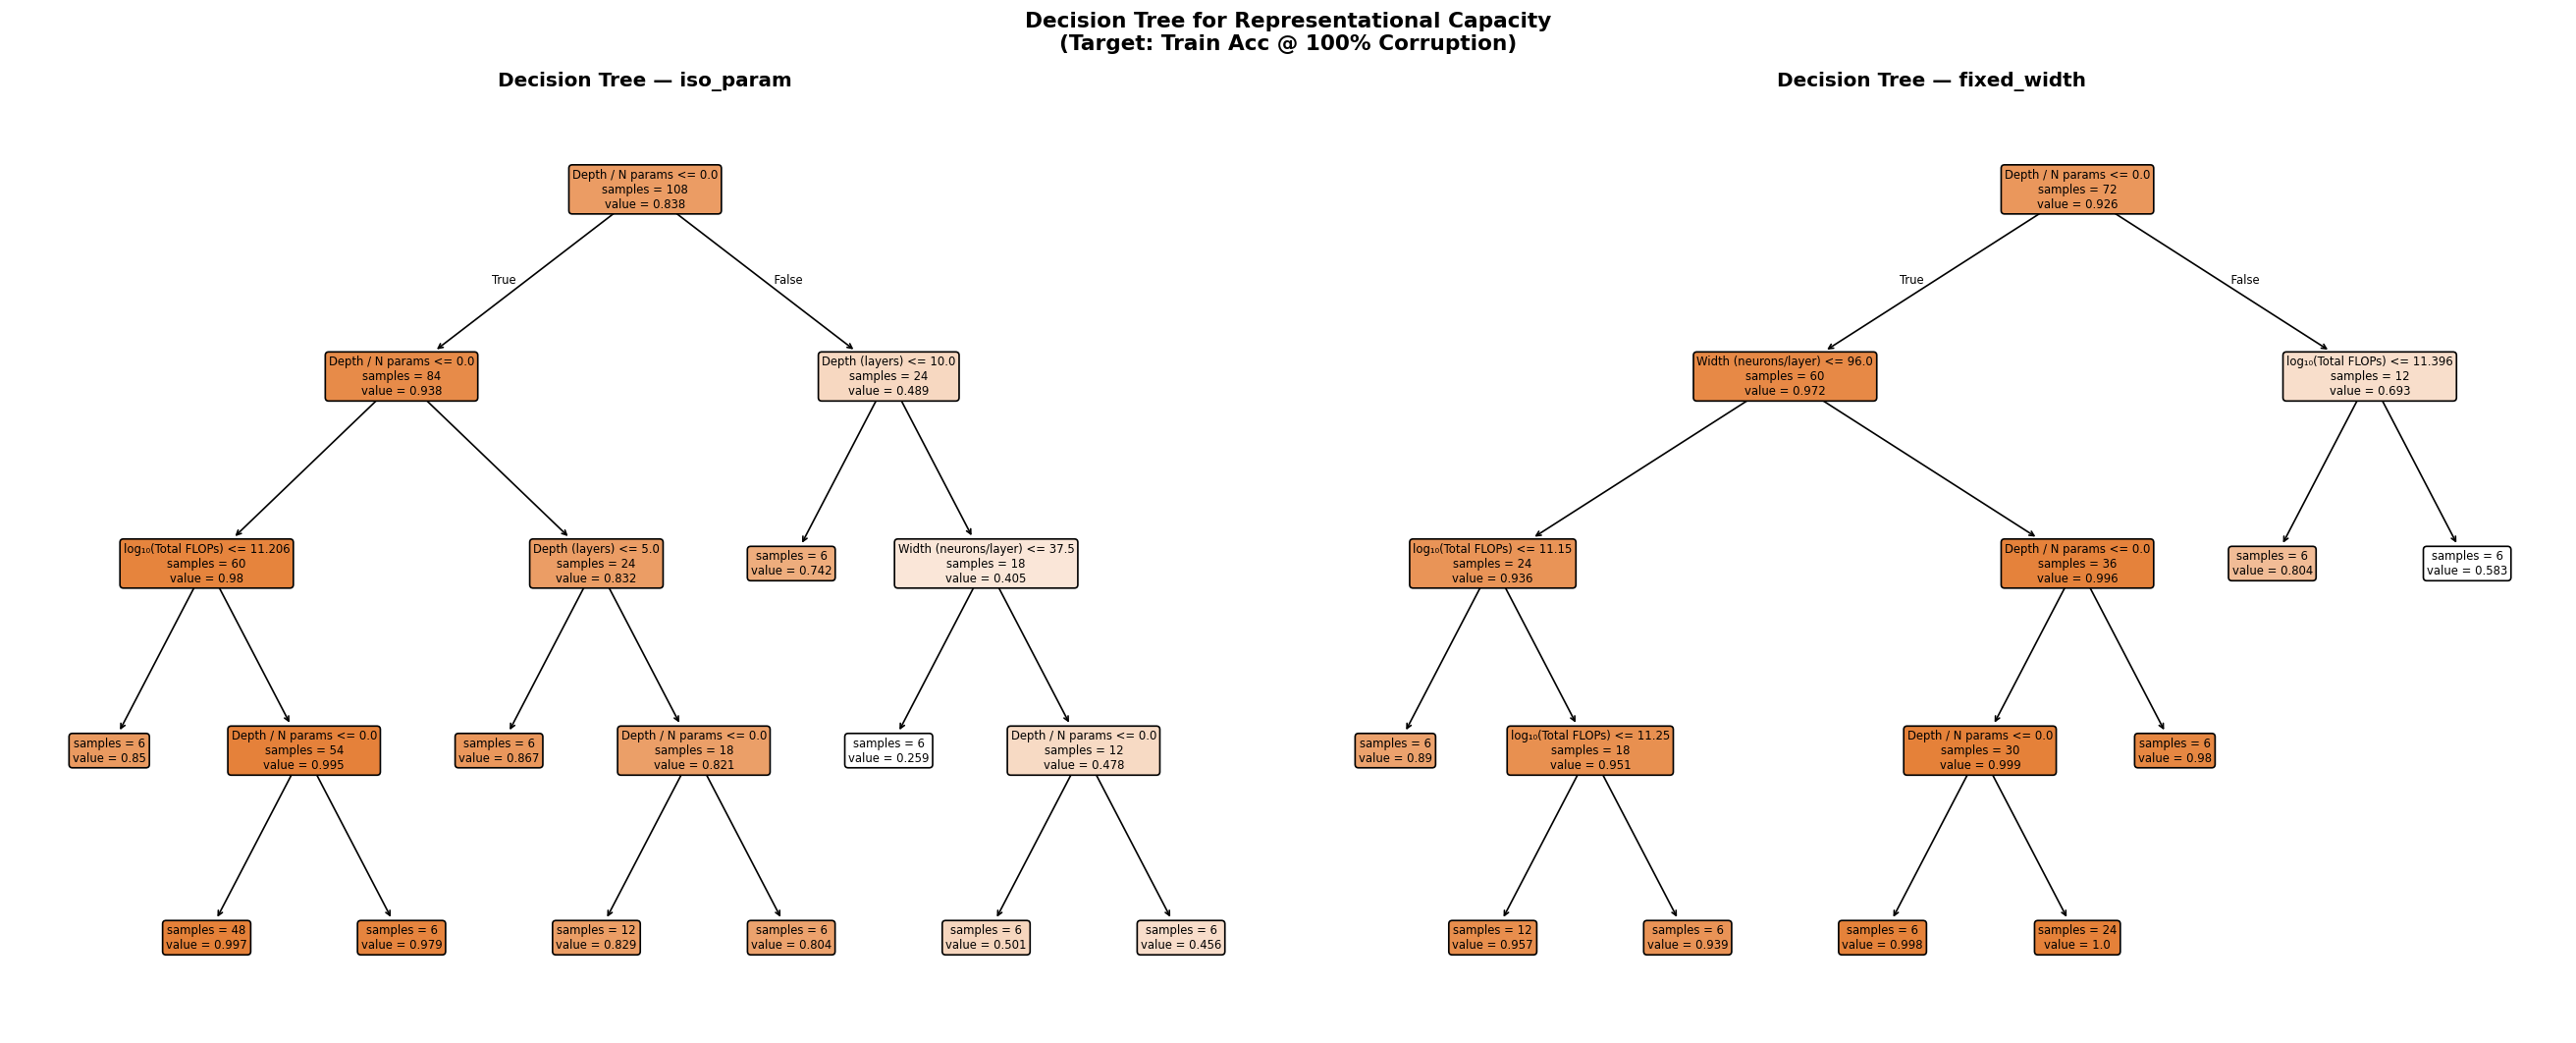

In [ ]:
# ── Decision Tree: Visual plots ───────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

for ax, dt, regime_label, color in [
    (axes[0], dt_iso,   'iso_param',   '#2271b3'),
    (axes[1], dt_fixed, 'fixed_width', '#d55e00')
]:
    feature_display = [FEATURE_LABELS.get(f, f) for f in FEATURES]
    plot_tree(dt, feature_names=feature_display, filled=True, rounded=True,
              fontsize=7, ax=ax, impurity=False, precision=3)
    ax.set_title(f'Decision Tree — {regime_label}', fontweight='bold', fontsize=12)

fig.suptitle('Decision Tree for Representational Capacity\n'
             '(Target: Train Acc @ 100% Corruption)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

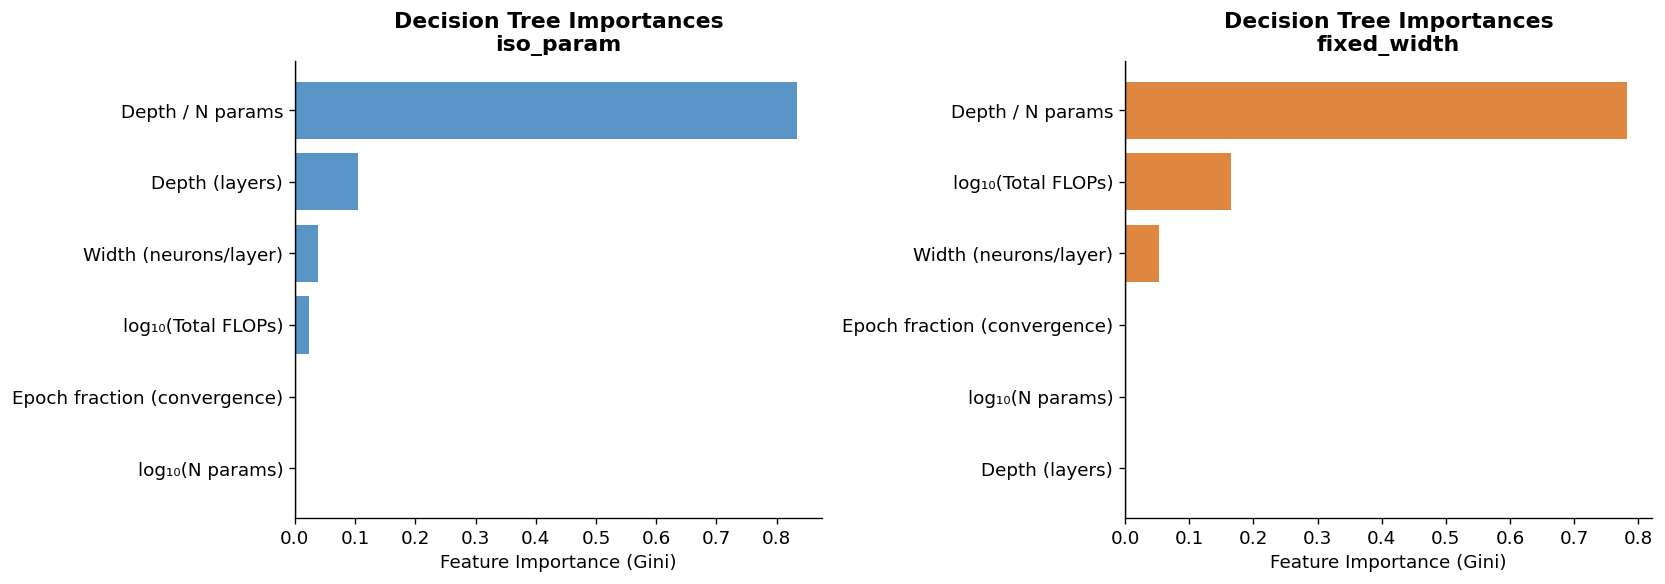

In [ ]:
# ── Decision Tree: Feature Importance Comparison ─────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dt, regime_label, color in [
    (axes[0], dt_iso,   'iso_param',   '#2271b3'),
    (axes[1], dt_fixed, 'fixed_width', '#d55e00')
]:
    imp = pd.Series(dt.feature_importances_, index=FEATURES).sort_values()
    labels = [FEATURE_LABELS.get(f, f) for f in imp.index]
    ax.barh(labels, imp.values, color=color, alpha=0.75)
    ax.set_xlabel('Feature Importance (Gini)')
    ax.set_title(f'Decision Tree Importances\n{regime_label}', fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('dt_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Model 4 — Random Forest + SHAP (Black-Box + Explainable AI)

**Purpose:** Random Forest captures complex non-linear interactions and depth-width joint effects that linear models and shallow trees miss.  
**XAI Framework:** SHAP (SHapley Additive exPlanations) assigns each feature a contribution value for *each individual prediction*, grounded in game-theory (Shapley values). This gives us:
- **Global importance** — which features matter most overall
- **Directional effects** — does depth *increase* or *decrease* capacity?
- **Individual explanations** — why does a specific deep/shallow model have high/low capacity?
- **Interaction detection** — does depth interact with width (especially important for iso_param)?

In [ ]:
# ── Model 4: Random Forest ────────────────────────────────────────────────────

def fit_rf(X, y, feature_names, regime_label):
    rf = RandomForestRegressor(n_estimators=500, max_depth=None,
                               min_samples_leaf=2, max_features='sqrt',
                               random_state=SEED, n_jobs=-1)
    rf.fit(X, y)

    cv    = KFold(n_splits=10, shuffle=True, random_state=SEED)
    cv_r2 = cross_val_score(rf, X, y, cv=cv, scoring='r2')

    print(f'\n{"═"*60}')
    print(f' Random Forest — {regime_label}')
    print(f'{"═"*60}')
    # print(f'  R² (OOB)          : {rf.oob_score if hasattr(rf, "oob_score_") else "N/A"}')
    print(f'  R² (train)        : {r2_score(y, rf.predict(X)):.4f}')
    print(f'  R² (10-fold CV)   : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
    return rf

rf_iso   = fit_rf(X_iso,   y_iso,   FEATURES, 'iso_param')
rf_fixed = fit_rf(X_fixed, y_fixed, FEATURES, 'fixed_width')


════════════════════════════════════════════════════════════
 Random Forest — iso_param
════════════════════════════════════════════════════════════
  R² (train)        : 0.9975
  R² (10-fold CV)   : 0.9925 ± 0.0071

════════════════════════════════════════════════════════════
 Random Forest — fixed_width
════════════════════════════════════════════════════════════
  R² (train)        : 0.9958
  R² (10-fold CV)   : 0.9896 ± 0.0076


In [ ]:
# ── SHAP: Compute Shapley Values ──────────────────────────────────────────────

print('Computing SHAP values (TreeExplainer — exact for Random Forest)...')

explainer_iso   = shap.TreeExplainer(rf_iso)
explainer_fixed = shap.TreeExplainer(rf_fixed)

shap_iso   = explainer_iso.shap_values(X_iso)
shap_fixed = explainer_fixed.shap_values(X_fixed)

print(f'  iso_param   SHAP matrix: {shap_iso.shape}')
print(f'  fixed_width SHAP matrix: {shap_fixed.shape}')

# Helper: prettier feature names for SHAP plots
FEATURE_DISPLAY = [FEATURE_LABELS[f] for f in FEATURES]

Computing SHAP values (TreeExplainer — exact for Random Forest)...
  iso_param   SHAP matrix: (108, 6)
  fixed_width SHAP matrix: (72, 6)


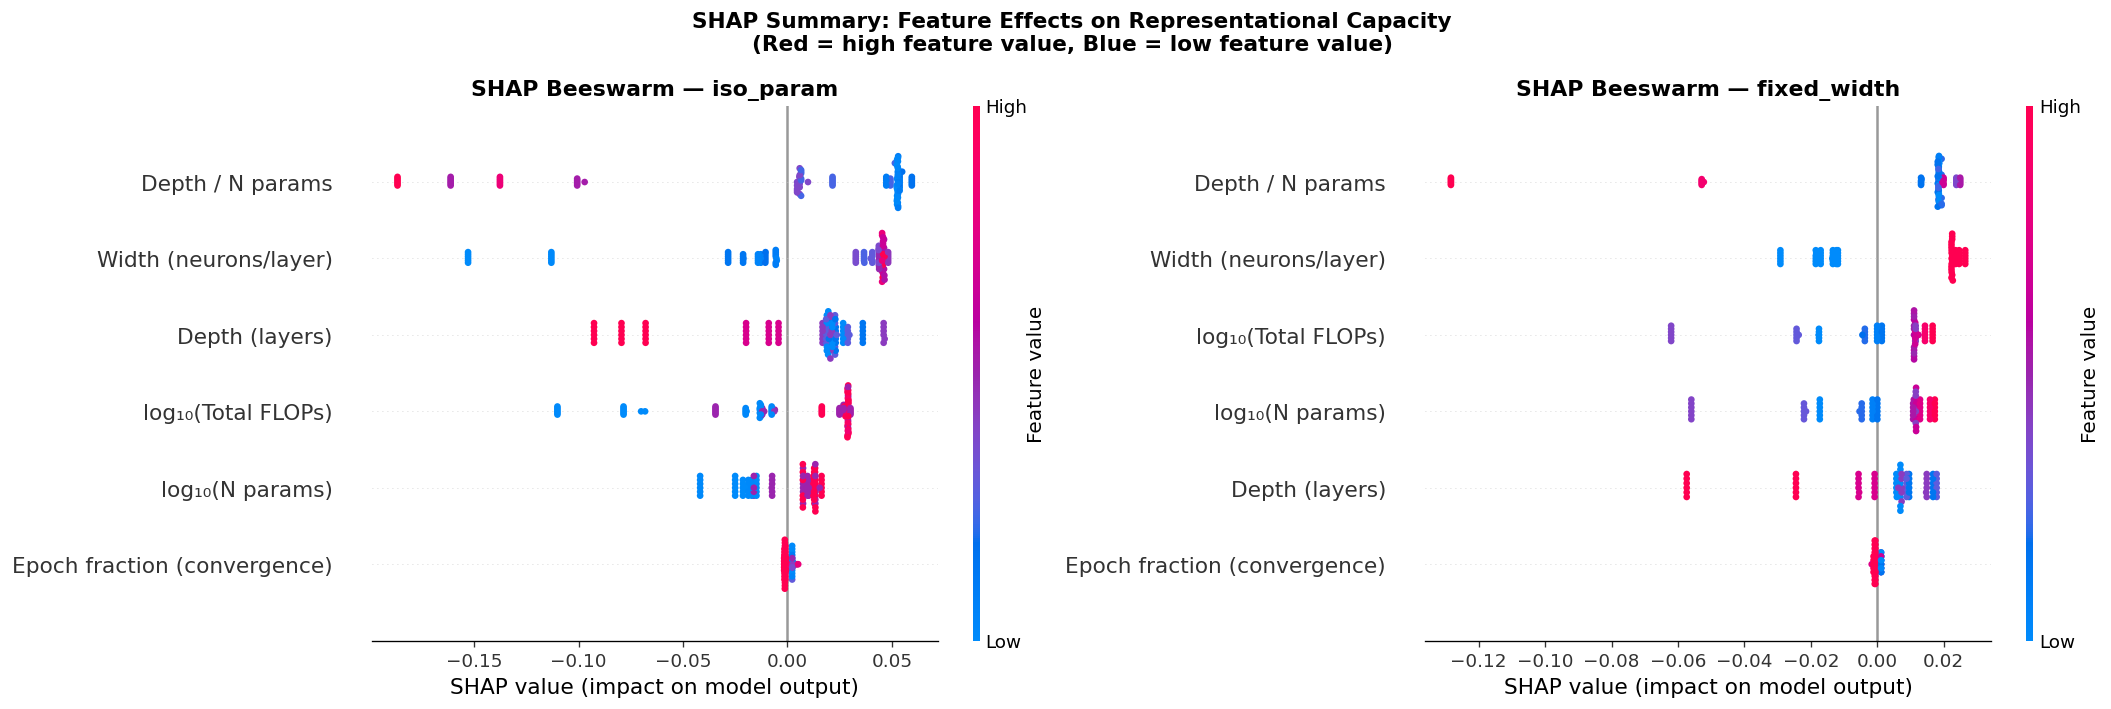


── Reading this plot ──
  depth row: red dots on the right → HIGH depth → INCREASES capacity
             red dots on the left  → HIGH depth → DECREASES capacity
  Features sorted by mean |SHAP| = global importance


In [ ]:
# ── SHAP Plot 1: Global Summary (Beeswarm) ────────────────────────────────────
#
# Each dot = one observation.
# X-axis = SHAP value (positive → increases predicted capacity).
# Colour  = feature value (red = high, blue = low).
# This reveals DIRECTION + MAGNITUDE of each feature's effect.

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plt.sca(axes[0])
shap.summary_plot(shap_iso, X_iso, feature_names=FEATURE_DISPLAY,
                  show=False, plot_size=None)
axes[0].set_title('SHAP Beeswarm — iso_param', fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(shap_fixed, X_fixed, feature_names=FEATURE_DISPLAY,
                  show=False, plot_size=None)
axes[1].set_title('SHAP Beeswarm — fixed_width', fontweight='bold')

fig.suptitle('SHAP Summary: Feature Effects on Representational Capacity\n'
             '(Red = high feature value, Blue = low feature value)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n── Reading this plot ──')
print('  depth row: red dots on the right → HIGH depth → INCREASES capacity')
print('             red dots on the left  → HIGH depth → DECREASES capacity')
print('  Features sorted by mean |SHAP| = global importance')

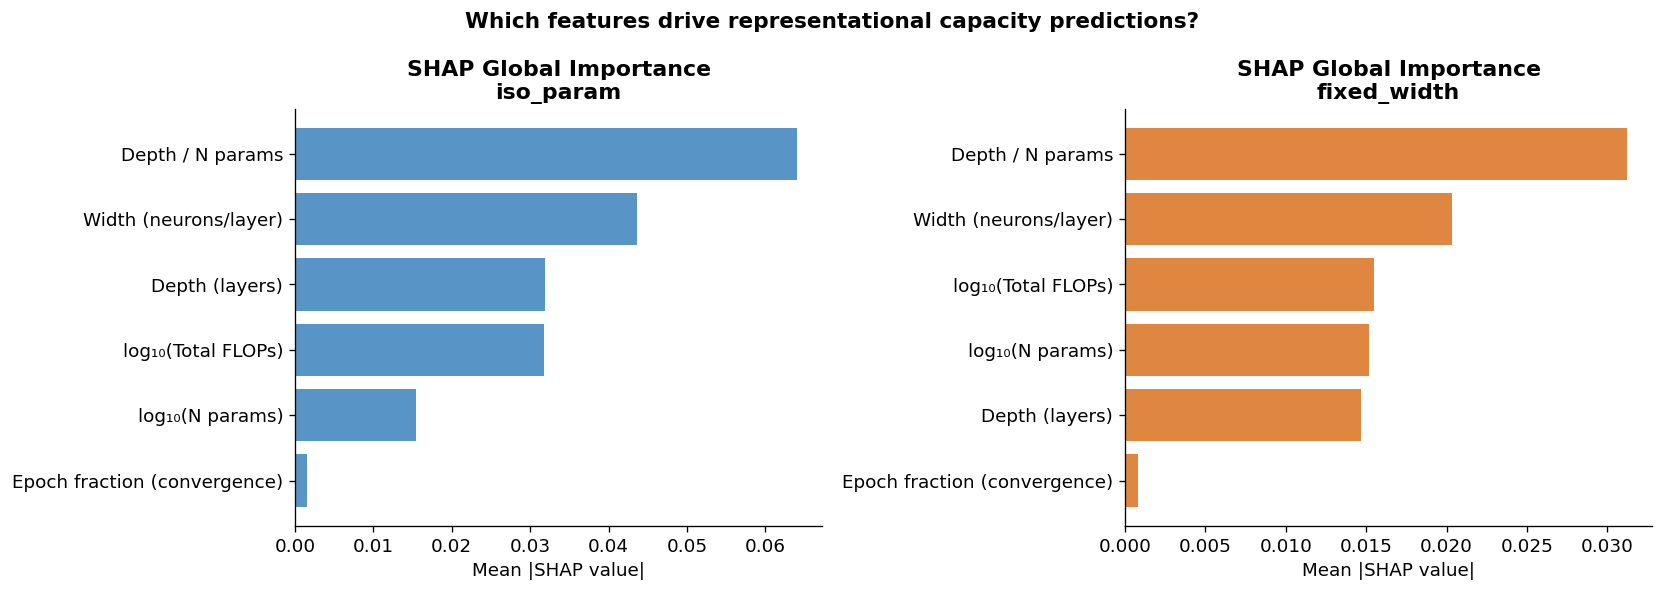

In [ ]:
# ── SHAP Plot 2: Mean |SHAP| Bar Chart (Global Importance) ────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, shap_vals, X_data, regime_label, color in [
    (axes[0], shap_iso,   X_iso,   'iso_param',   '#2271b3'),
    (axes[1], shap_fixed, X_fixed, 'fixed_width', '#d55e00')
]:
    mean_abs = np.abs(shap_vals).mean(axis=0)
    imp_df   = pd.Series(mean_abs, index=FEATURE_DISPLAY).sort_values()
    ax.barh(imp_df.index, imp_df.values, color=color, alpha=0.75)
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(f'SHAP Global Importance\n{regime_label}', fontweight='bold')

plt.suptitle('Which features drive representational capacity predictions?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()

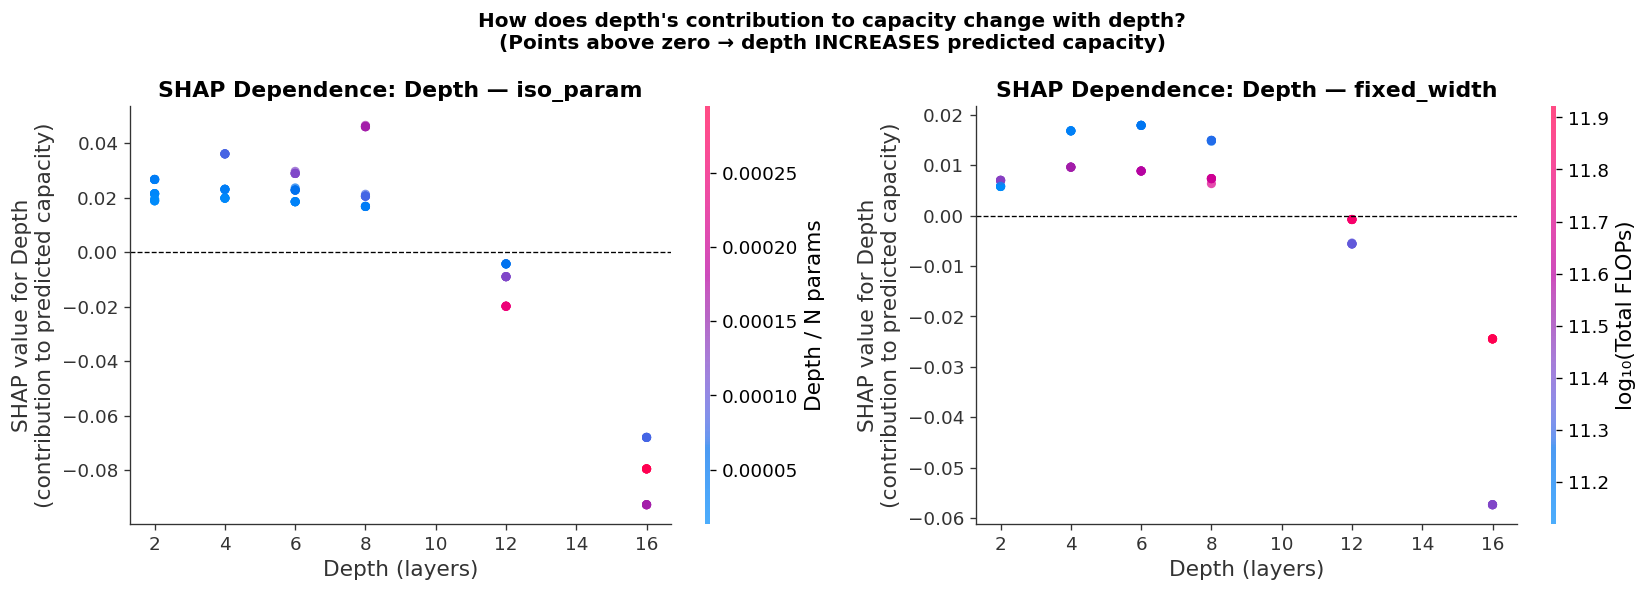

In [ ]:
# ── SHAP Plot 3: Dependence Plot — Depth (main hypothesis variable) ───────────
#
# Shows how depth's SHAP value changes as depth increases.
# Colour shows a second feature (auto-selected by SHAP as max interaction).
# A rising line → deeper = higher capacity.

depth_idx = FEATURES.index('depth')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, shap_vals, X_data, regime_label in [
    (axes[0], shap_iso,   X_iso,   'iso_param'),
    (axes[1], shap_fixed, X_fixed, 'fixed_width')
]:
    plt.sca(ax)
    shap.dependence_plot(
        depth_idx, shap_vals, X_data,
        feature_names=FEATURE_DISPLAY,
        ax=ax, show=False, dot_size=30, alpha=0.7
    )
    ax.set_title(f'SHAP Dependence: Depth — {regime_label}', fontweight='bold')
    ax.set_xlabel('Depth (layers)')
    ax.set_ylabel('SHAP value for Depth\n(contribution to predicted capacity)')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.suptitle('How does depth\'s contribution to capacity change with depth?\n'
             '(Points above zero → depth INCREASES predicted capacity)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_depth_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── SHAP Plot 4: Waterfall for Specific Cases ─────────────────────────────────
#
# Explain ONE prediction: the deepest (depth=16) model in each regime.
# A waterfall chart decomposes the prediction into per-feature contributions.

def explain_case(X_data, y_data, shap_vals, regime_label, explainer,
                 feature_names, target_depth=16):
    """Show SHAP waterfall for the deepest model observation."""
    depth_idx_col = feature_names.index('depth')

    # Find index of a depth=16 case with median capacity
    mask  = X_data[:, depth_idx_col] == target_depth
    idxs  = np.where(mask)[0]
    if len(idxs) == 0:
        print(f'No depth={target_depth} rows in {regime_label}')
        return
    # Pick the one closest to the median target among depth=16
    median_y = np.median(y_data[idxs])
    pick     = idxs[np.argmin(np.abs(y_data[idxs] - median_y))]

    print(f'\n{regime_label} — explaining observation {pick} (depth=16):')
    print(f'  Actual capacity: {y_data[pick]:.4f}')
    print(f'  Predicted:       {explainer.expected_value + shap_vals[pick].sum():.4f}')
    print(f'  Base value:      {explainer.expected_value:.4f}')

    # Build Explanation object for waterfall
    exp = shap.Explanation(
        values         = shap_vals[pick],
        base_values    = explainer.expected_value,
        data           = X_data[pick],
        feature_names  = FEATURE_DISPLAY
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    plt.sca(ax)
    shap.waterfall_plot(exp, show=False, max_display=len(feature_names))
    ax.set_title(f'SHAP Waterfall — {regime_label}\n'
                 f'Depth=16, Capacity={y_data[pick]:.3f}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'shap_waterfall_{regime_label}.png', dpi=150, bbox_inches='tight')
    plt.show()

explain_case(X_iso,   y_iso,   shap_iso,   'iso_param',   explainer_iso,   FEATURES)
explain_case(X_fixed, y_fixed, shap_fixed, 'fixed_width', explainer_fixed, FEATURES)


iso_param — explaining observation 69 (depth=16):
  Actual capacity: 0.4991


TypeError: unsupported format string passed to numpy.ndarray.__format__

---
## Model Comparison

In [ ]:
# ── 5. Model Comparison Table ─────────────────────────────────────────────────

def cv_metrics(model, X, y, name):
    cv  = KFold(n_splits=10, shuffle=True, random_state=SEED)
    r2s = cross_val_score(model, X, y, cv=cv, scoring='r2')
    maes = cross_val_score(model, X, y, cv=cv,
                           scoring='neg_mean_absolute_error')
    return {'Model': name,
            'CV R² (mean)': r2s.mean(),
            'CV R² (std)':  r2s.std(),
            'CV MAE (mean)': (-maes).mean(),
            'CV MAE (std)':  (-maes).std()}

from sklearn.linear_model import Ridge

# Use Ridge as the linear model stand-in for fair CV (OLS via statsmodels above was for inference)
ols_sk_iso   = LinearRegression()
ols_sk_fixed = LinearRegression()

lasso_iso_sk   = Lasso(alpha=lasso_iso.alpha_,   max_iter=10000)
lasso_fixed_sk = Lasso(alpha=lasso_fixed.alpha_, max_iter=10000)

dt_iso_cv   = DecisionTreeRegressor(max_depth=4, min_samples_leaf=3, random_state=SEED)
dt_fixed_cv = DecisionTreeRegressor(max_depth=4, min_samples_leaf=3, random_state=SEED)

rf_iso_cv   = RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                    max_features='sqrt', random_state=SEED, n_jobs=-1)
rf_fixed_cv = RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                    max_features='sqrt', random_state=SEED, n_jobs=-1)

rows_iso = [
    cv_metrics(ols_sk_iso,   X_iso_z, y_iso, 'OLS Linear'),
    cv_metrics(lasso_iso_sk, X_iso_z, y_iso, 'Lasso'),
    cv_metrics(dt_iso_cv,    X_iso,   y_iso, 'Decision Tree'),
    cv_metrics(rf_iso_cv,    X_iso,   y_iso, 'Random Forest'),
]

rows_fixed = [
    cv_metrics(ols_sk_fixed,   X_fixed_z, y_fixed, 'OLS Linear'),
    cv_metrics(lasso_fixed_sk, X_fixed_z, y_fixed, 'Lasso'),
    cv_metrics(dt_fixed_cv,    X_fixed,   y_fixed, 'Decision Tree'),
    cv_metrics(rf_fixed_cv,    X_fixed,   y_fixed, 'Random Forest'),
]

comp_iso   = pd.DataFrame(rows_iso).set_index('Model')
comp_fixed = pd.DataFrame(rows_fixed).set_index('Model')

print('\n══ Model Comparison — iso_param ══')
print(comp_iso.round(4).to_string())
print('\n══ Model Comparison — fixed_width ══')
print(comp_fixed.round(4).to_string())
print('\nNote: R² and MAE here are for orientation only.')
print('      The key output is interpretation, not predictive performance.')


══ Model Comparison — iso_param ══
               CV R² (mean)  CV R² (std)  CV MAE (mean)  CV MAE (std)
Model                                                                
OLS Linear           0.8760       0.1568         0.0418        0.0080
Lasso                0.8735       0.1394         0.0450        0.0065
Decision Tree        0.9967       0.0025         0.0069        0.0022
Random Forest        0.9919       0.0088         0.0088        0.0035

══ Model Comparison — fixed_width ══
               CV R² (mean)  CV R² (std)  CV MAE (mean)  CV MAE (std)
Model                                                                
OLS Linear           0.6089       0.5459         0.0321        0.0095
Lasso                0.6166       0.4901         0.0343        0.0086
Decision Tree        0.9905       0.0075         0.0049        0.0021
Random Forest        0.9886       0.0087         0.0058        0.0023

Note: R² and MAE here are for orientation only.
      The key output is interpretatio

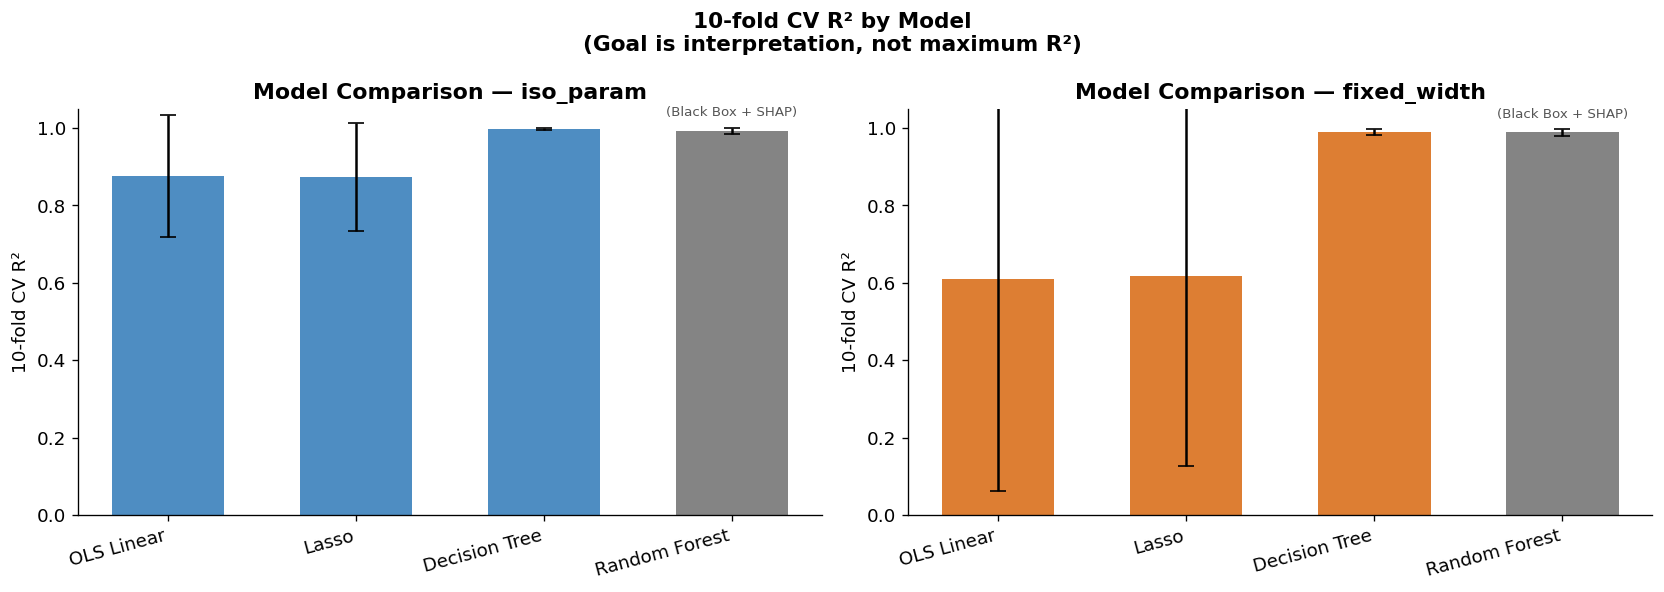

In [ ]:
# ── Comparison Plot ───────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, comp_df, regime_label, color in [
    (axes[0], comp_iso,   'iso_param',   '#2271b3'),
    (axes[1], comp_fixed, 'fixed_width', '#d55e00')
]:
    models = comp_df.index.tolist()
    r2s    = comp_df['CV R² (mean)'].values
    errs   = comp_df['CV R² (std)'].values
    x_pos  = range(len(models))

    bars = ax.bar(x_pos, r2s, yerr=errs, capsize=5,
                  color=[color if m != 'Random Forest' else '#666666' for m in models],
                  alpha=0.8, width=0.6)
    ax.set_xticks(list(x_pos))
    ax.set_xticklabels(models, rotation=15, ha='right')
    ax.set_ylabel('10-fold CV R²')
    ax.set_title(f'Model Comparison — {regime_label}', fontweight='bold')
    ax.set_ylim(0, 1.05)

    # Label RF as black box
    rf_idx = models.index('Random Forest')
    ax.text(rf_idx, r2s[rf_idx] + errs[rf_idx] + 0.03,
            '(Black Box + SHAP)', ha='center', fontsize=8, color='#555555')

fig.suptitle('10-fold CV R² by Model\n(Goal is interpretation, not maximum R²)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Synthesis: What Do the Models Tell Us?

### Interpretation Template

Run the cells above, then complete this section with your actual results.

---

#### iso_param Regime (n_params ≈ constant, depth ↑, width ↓)

*This is the crucial test — any effect of depth is **not** explained by having more parameters.*

| Model | Direction of depth effect | Significance / Strength |
|---|---|---|
| OLS | `[positive / negative / near zero]` | p = `[value]`, β = `[value]` |
| Lasso | `[survived / zeroed out]` | coef = `[value]` |
| Decision Tree | `[depth appears at root / mid-tree / not at all]` | importance = `[value]` |
| SHAP (RF) | `[red right / red left]` in beeswarm | mean|SHAP| = `[value]` |

**Verdict (iso_param):** `[Depth increases / decreases / does not significantly affect]` representational capacity even when parameter count is held constant.

---

#### fixed_width Regime (depth ↑, n_params ↑ — confounded)

| Model | Direction of depth effect | Significance / Strength |
|---|---|---|
| OLS | `[+/-/~0]` | p = `[value]`, β = `[value]` |
| SHAP (RF) | `[direction]` | mean|SHAP| = `[value]` |

**Verdict (fixed_width):** `[...]`  
Caveat: in this regime, depth and n_params are **collinear** — depth's coefficient partially reflects the extra parameters, not architecture shape alone.

---

#### Overall Conclusion

- If `depth` has a **positive, significant effect in iso_param** → hypothesis **supported**: deeper architectures encode more capacity per parameter.
- If `log_n_params` dominates in fixed_width but depth is weak in iso_param → capacity is driven by **parameter count**, not depth per se.
- If depth's SHAP dependence plot shows a **non-linear pattern** (e.g., plateau at depth ≥ 8) → hypothesis is partially supported but saturates.

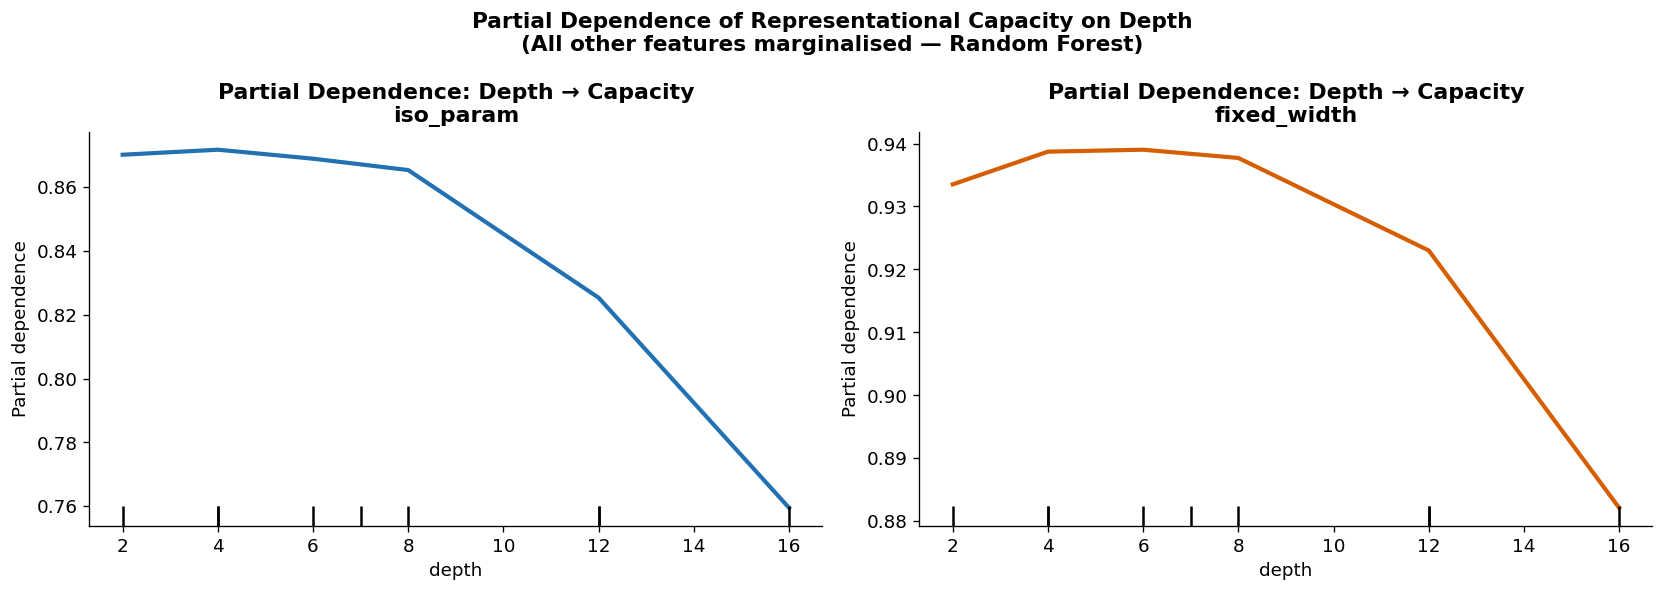


── Reading this plot ──
  Upward slope → depth increases capacity (supports hypothesis)
  Flat line    → depth has no effect on capacity
  Downward     → deeper models have LESS capacity (contradicts hypothesis)
  Non-linear   → threshold / saturation effects exist


In [ ]:
# ── Bonus: Partial Dependence — Depth on Capacity (both regimes) ──────────────
#
# Marginalises out all other features to show the pure depth-capacity curve.

from sklearn.inspection import PartialDependenceDisplay

depth_idx = FEATURES.index('depth')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, rf, X_data, regime_label, color in [
    (axes[0], rf_iso,   X_iso,   'iso_param',   '#2271b3'),
    (axes[1], rf_fixed, X_fixed, 'fixed_width', '#d55e00')
]:
    PartialDependenceDisplay.from_estimator(
        rf, X_data, [depth_idx],
        feature_names=FEATURES,
        ax=ax, line_kw={'color': color, 'linewidth': 2.5}
    )
    ax.set_title(f'Partial Dependence: Depth → Capacity\n{regime_label}', fontweight='bold')
    ax.set_xlabel('Depth (layers)')
    ax.set_ylabel('Predicted Representational Capacity\n(partial dependence)')
    ax.axhline(ax.get_ylim()[0], color='black', linewidth=0.5)

fig.suptitle('Partial Dependence of Representational Capacity on Depth\n'
             '(All other features marginalised — Random Forest)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('partial_dependence_depth.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n── Reading this plot ──')
print('  Upward slope → depth increases capacity (supports hypothesis)')
print('  Flat line    → depth has no effect on capacity')
print('  Downward     → deeper models have LESS capacity (contradicts hypothesis)')
print('  Non-linear   → threshold / saturation effects exist')